In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

In [62]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [70]:
from nbodykit.lab import cosmology as n_cosmology
#c      = n_cosmology.Planck15
#n_cosmology.P_k_max=100
c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [97]:
def kernel_lin(ks, R=1, nbins=100):
    dx = 2*R
    results = []
    r = np.linspace(0, dx, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [129]:
def kernel_NL(ks, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(0, dx, nbins)
    xi = cf_nl(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

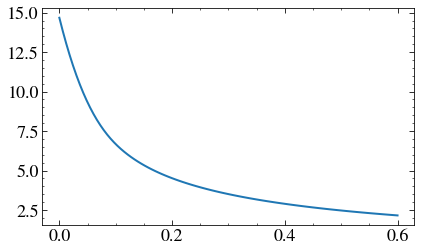

In [105]:
dx=2*R
nbins=100
r = np.linspace(0, dx, nbins)
xi = cf_lin(r)
plt.plot(r, xi)

In [98]:
def W_R(k, R=1):
    R = 2*R
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [99]:
def V_excl(R=1):
    R = 2*R
    return (4*np.pi*R**3)/3

In [100]:
def pk_random(k, R):
    result2 = -V_excl(R)*W_R(k,R)
    return result2

In [101]:
def fit_pow(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1, kernel_type="lin"):
    #bias_k = scale_dependent_bias(logk, a, b, c, d, logk0)
    bias_k = 1

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        kernel = kernel_new(10**logk, R=R)
    elif kernel_type == "nl":
        kernel = kernel_NL(10**logk, R=R)
    
    result1 = bias_k*Plin(10**logk) - bias_k*kernel - V_excl(R)*W_R(10**logk, R)
    
    return result1

In [118]:
y = fit_pow(logks, R=R)

In [119]:
y1 =  Plin(10**logks)-kernel_lin(10**logks, R=R)+pk_random(ks,R)

(-10.0, 10.0)

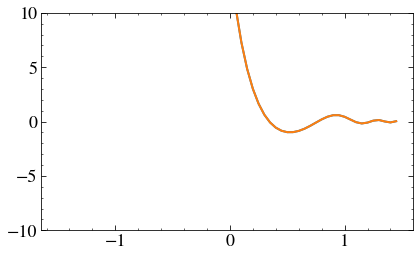

In [121]:
plt.plot(logks,y)
plt.plot(logks,y1)
plt.ylim(-10,10)

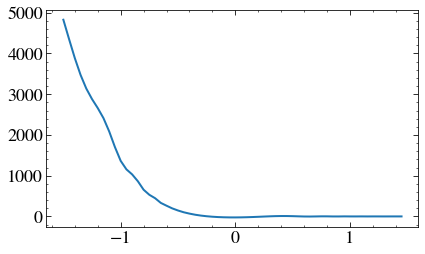

In [116]:
plt.plot(logks, fit_pow(logks,R), label="Clustered distribution")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

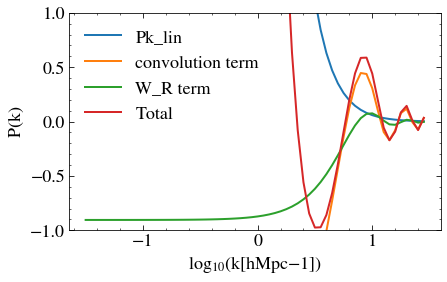

In [160]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3

plt.plot(logks, Plin(10**logks), label="Pk_lin")
plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow(logks,R=R), label="Total")
plt.ylim(-1,1)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

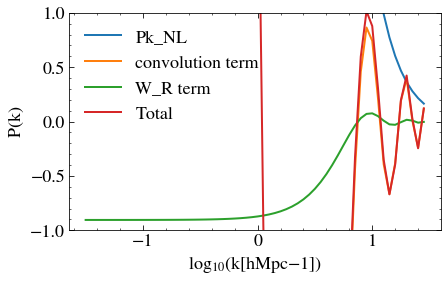

In [161]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3

plt.plot(logks, Pnl(10**logks), label="Pk_NL")
plt.plot(logks, -kernel_NL(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow(logks,R=R, kernel_type="nl"), label="Total")
#plt.ylim(-15,15)
plt.ylim(-1,1)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

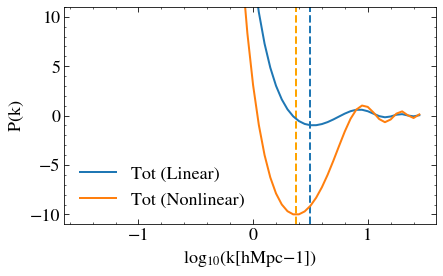

In [172]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3


plt.plot(logks, fit_pow(logks,R=R), label="Tot (Linear)")
plt.plot(logks, fit_pow(logks,R=R, kernel_type="nl"), label="Tot (Nonlinear)")
plt.vlines(0.5, ymin=-11, ymax=11, linestyle="dashed")
plt.vlines(0.37, ymin=-11, ymax=11, linestyle="dashed", color="orange")
plt.ylim(-11,11)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

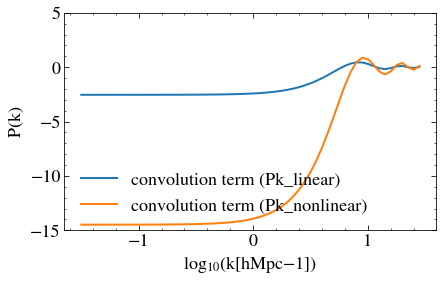

In [145]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3

plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term (Pk_linear)")
plt.plot(logks, -kernel_NL(10**logks, R=R), label="convolution term (Pk_nonlinear)")

plt.ylim(-15,5)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

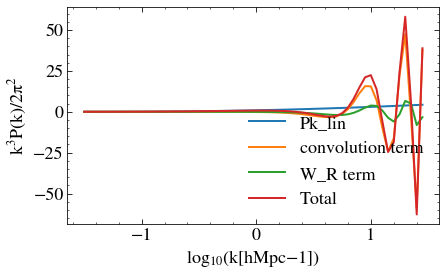

In [176]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3
kcoef = ks**3/(2*np.pi**2)

plt.plot(logks, kcoef*Plin(10**logks), label="Pk_lin")
plt.plot(logks, -kcoef*kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, kcoef*pk_random(ks,R), label="W_R term")
plt.plot(logks, kcoef*fit_pow(logks,R=R), label="Total")
#plt.ylim(-1,)

plt.ylabel(r"$\rm k^3 P(k)/2\pi^2$")
plt.legend()
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0, 0.5, '$\\rm k^3 P(k)/2\\pi^2$')

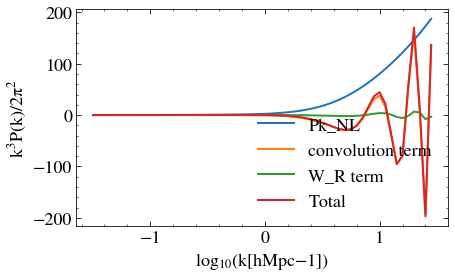

In [183]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3

plt.plot(logks, kcoef*Pnl(10**logks), label="Pk_NL")
plt.plot(logks, -kcoef*kernel_NL(10**logks, R=R), label="convolution term")
plt.plot(logks, kcoef*pk_random(ks,R), label="W_R term")
plt.plot(logks, kcoef*fit_pow(logks,R=R, kernel_type="nl"), label="Total")
#plt.ylim(-70,70)
#plt.ylim(-1,1)
plt.legend()
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

plt.ylabel(r"$\rm k^3 P(k)/2\pi^2$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

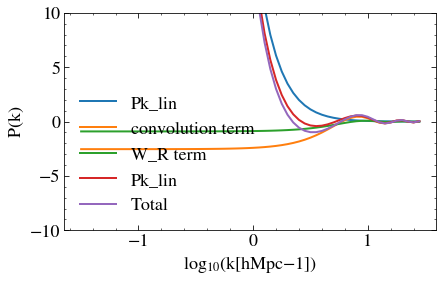

In [124]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3

plt.plot(logks, Plin(10**logks), label="Pk_lin")
plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, Plin(10**logks)-kernel_lin(10**logks, R=R), label="Pk_lin")

plt.plot(logks, fit_pow(logks,R=R), label="Total")
plt.ylim(-10,10)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

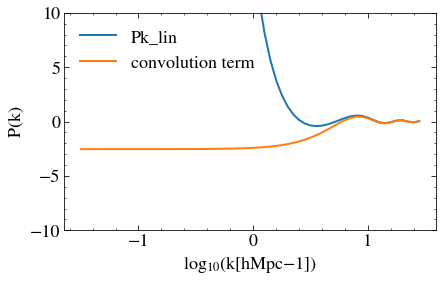

In [112]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3

plt.plot(logks, Plin(10**logks)-kernel_lin(10**logks, R=R), label="Pk_lin")
plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
#plt.plot(logks, pk_random(ks,R), label="W_R term")
#plt.plot(logks, fit_pow(logks,R), label="Total")
plt.ylim(-10,10)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

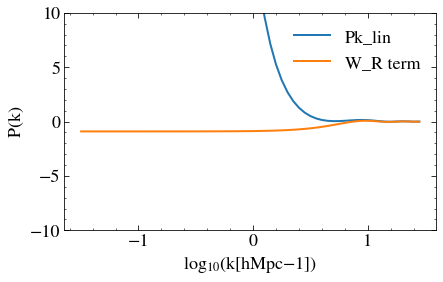

In [114]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3

plt.plot(logks, Plin(10**logks)+pk_random(ks,R), label="Pk_lin")
#plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
#plt.plot(logks, fit_pow(logks,R), label="Total")
plt.ylim(-10,10)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

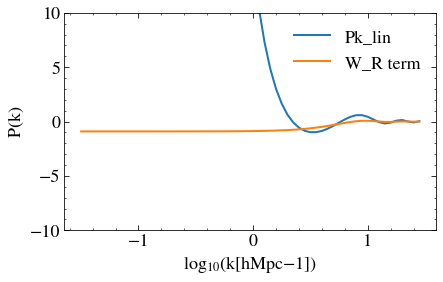

In [115]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3

plt.plot(logks, Plin(10**logks)-kernel_lin(10**logks, R=R)+pk_random(ks,R), label="Pk_lin")
#plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
#plt.plot(logks, fit_pow(logks,R), label="Total")
plt.ylim(-10,10)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

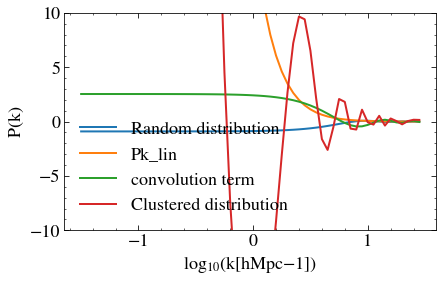

In [108]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3
plt.plot(logks, pk_random(ks,R), label="Random distribution")
plt.plot(logks, Plin(10**logks), label="Pk_lin")
plt.plot(logks, kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, fit_pow(logks,R), label="Clustered distribution")
plt.ylim(-10,10)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

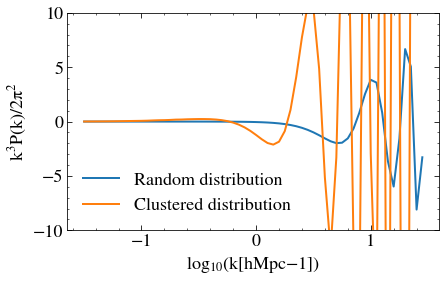

In [103]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.3
kcoef = ks**3/(2*np.pi**2)
plt.plot(logks, kcoef*pk_random(ks,R), label="Random distribution")
plt.plot(logks, kcoef*fit_pow(logks,R), label="Clustered distribution")
plt.ylim(-10,10)
plt.legend()
plt.ylabel(r"$\rm k^3 P(k)/2\pi^2$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")